# Creation of a neural network with Keras for the classification of products from the data set fashion_mnist.

## Imports

In [49]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras

from keras import layers, models
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout, Activation, Flatten, BatchNormalization, Conv2D, MaxPooling2D
from keras.utils import to_categorical
from keras.optimizers import Adam, Nadam
from keras.callbacks import EarlyStopping, LearningRateScheduler, ReduceLROnPlateau
from keras.regularizers import l2
from keras.datasets import fashion_mnist

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import json
from datetime import datetime
from tabulate import tabulate

%matplotlib inline

import os
# macOS specipic workaround for not working GPU on tf v2.16.1
# os.environ['TF_USE_LEGACY_KERAS'] = '1'
# When = 3, the messages (1 - informational(I), 2 - warnings(W) and 3- errors(E)) will not be logged during code execution.
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [36]:
print("TensorFlow", tf.__version__)
# Ensure we see the GPU in device list in the macOS.
# print('Visible Devices: ', tf.config.get_visible_devices())
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  details = tf.config.experimental.get_device_details(gpus[0])
  print("GPU details: ", details)


TensorFlow 2.16.1
GPU details:  {'device_name': 'METAL'}


In [56]:
def plot_model(history=None, model_version='v1'):
    plt.figure(figsize=(10, 8))
    plt.plot(history.history['accuracy'],
             label='Training Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'],
             label='Validation Accuracy', color='green', marker='x')
    plt.plot(history.history['loss'],
             label='Training Loss', color='red', linestyle='--')
    plt.plot(history.history['val_loss'], label='Validation Loss',
             color='goldenrod', linestyle='--', marker='x')
    plt.title(
        f'Model {model_version} - Training and Validation Performance', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy and Loss (Scored Separately)', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


def save_metrics(loss, accuracy, file_name="model_metrics.json", comment=""):
  data = {"Created_at": datetime.now().isoformat(), "Loss": loss, "Accuracy": accuracy, "Comment": comment}
  try:
    # Try to load existing data from the file
    with open(file_name, "r") as f:
      existing_data = json.load(f)
  except FileNotFoundError:
    # If file doesn't exist, create an empty list
    existing_data = []
  # Write data (empty list or existing data)
  with open(file_name, "w") as f:
    json.dump(existing_data + [data], f, indent=4)  # Directly append new data



def display_metrics(file_name="model_metrics.json"):
  """Prints metrics (loss, accuracy, comment) from a JSON file in a table format.

  Args:
    file_name: String, the name of the JSON file containing metrics (default: "model_metrics.json").
  """
  try:
    with open(file_name, "r") as f:
      metrics_data = json.load(f)
  except FileNotFoundError:
    print("No metrics file found.")
    return

  # Check if entries have all required keys before accessing them
  if not all(key in entry for entry in metrics_data for key in ["Loss", "Accuracy", "Comment"]):
    print("Warning: Some entries in the metrics file might be missing required keys.")

  headers = ["Loss", "Accuracy", "Comment"]
  rows = [[entry.get("Loss"), entry.get("Accuracy"), entry.get("Comment")] for entry in metrics_data]
  print(tabulate(rows, headers=headers, tablefmt="pretty"))


## Load data

In [10]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [11]:
X_train = X_train.reshape(X_train.shape[0], 28 * 28) / 255
X_test = X_test.reshape(X_test.shape[0], 28 * 28) / 255

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

## Multi Layer Regular Neural Net

In [12]:
model_v12 = Sequential(name='v12')
model_v12.add(Dense(256, activation='tanh', input_shape=(784,), name='v12_hidden1'))
model_v12.add(Dropout(0.2, name='v12_hidden2'))
model_v12.add(Dense(128, activation='tanh', name='v12_hidden3'))
model_v12.add(Dense(10, activation='softmax', name='v12_output'))

model_v12.compile(
    optimizer=Adam(learning_rate=0.0005),  # Reduced learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Define a learning rate scheduler
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return float(lr * tf.math.exp(-0.1))

lr_scheduler = LearningRateScheduler(scheduler)

model_v12.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "v12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ v12_hidden1 (Dense)             │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ v12_hidden2 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ v12_hidden3 (Dense)             │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ v12_output (Dense)              │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
%%time
history_model_v12 = model_v12.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stopping, lr_scheduler]
)



Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.7685 - loss: 0.6524 - val_accuracy: 0.8523 - val_loss: 0.4093 - learning_rate: 5.0000e-04
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.8564 - loss: 0.3958 - val_accuracy: 0.8565 - val_loss: 0.3899 - learning_rate: 5.0000e-04
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.8642 - loss: 0.3669 - val_accuracy: 0.8612 - val_loss: 0.3691 - learning_rate: 5.0000e-04
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.8762 - loss: 0.3431 - val_accuracy: 0.8777 - val_loss: 0.3357 - learning_rate: 5.0000e-04
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.8810 - loss: 0.3211 - val_accuracy: 0.8764 - val_loss: 0.3430 - learning_rate: 5.0000e-04
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.8866 - loss: 0.3078 - val_accuracy: 0.8848 - val_loss: 0.3207 - learning_rate: 5.0000e-04
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━

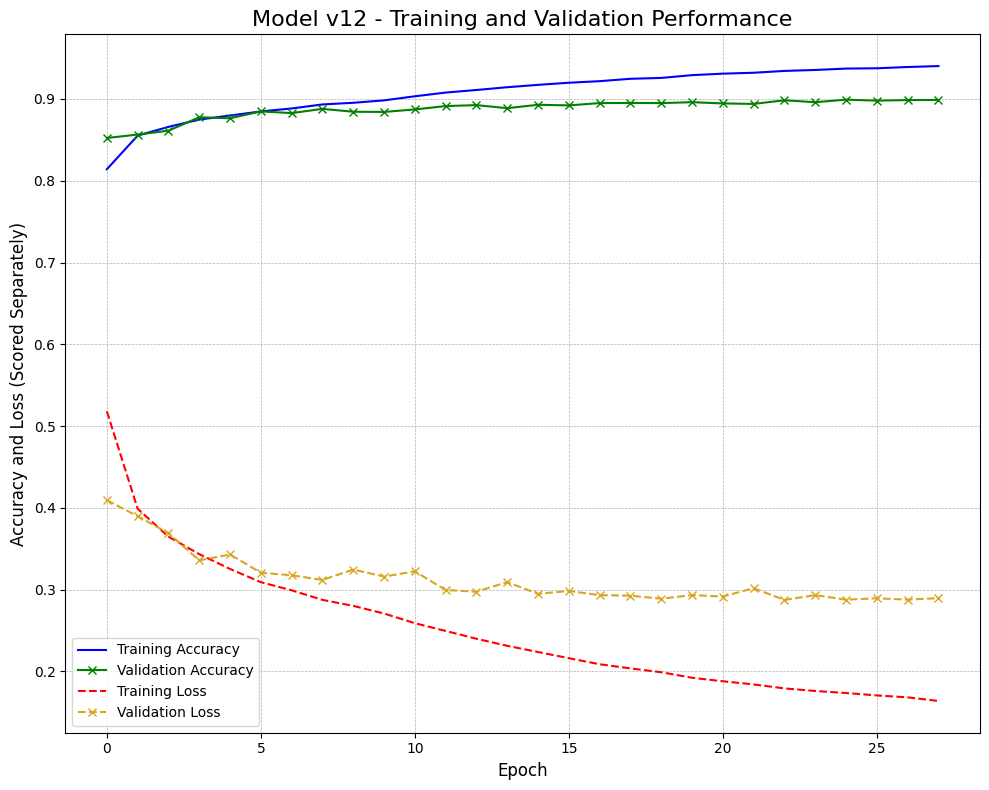

In [14]:
plot_model(history_model_v12, model_version='v12')

In [ ]:
# Evaluate the model
test_loss, test_acc = model_v12.evaluate(X_test, y_test, verbose=1)
save_metrics(loss=test_loss, accuracy=test_acc, file_name='model_metrics.json', comment='mulilayer regular neural net')
print(f'\nTest accuracy: {test_acc} Test loss: {test_loss}')
display_metrics(file_name='model_metrics.json')

### Model v12 Summary


* Accuracy on the train data is above `0.91`. Test Accuracy below `0.91`




## Conv2D v1

In [16]:
# Load and preprocess the Fashion MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0


# Add a channels dimension
x_train = X_train[..., tf.newaxis]
x_test = X_test[..., tf.newaxis]



In [17]:
# Define the model architecture v1

model_conv2d_v1 = Sequential(name='conv2d_v1')
model_conv2d_v1.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv2d_layer1'))
model_conv2d_v1.add(MaxPooling2D((2, 2), name='maxpool_layer1'))
model_conv2d_v1.add(Conv2D(64, (3, 3), activation='relu', name='conv2d_layer2'))
model_conv2d_v1.add(MaxPooling2D((2, 2), name='maxpool_layer2'))
model_conv2d_v1.add(Conv2D(64, (3, 3), activation='relu', name='conv2d_layer3'))
model_conv2d_v1.add(Flatten(name='flatten_layer'))
model_conv2d_v1.add(Dense(64, activation='relu', name='dense_layer1'))
model_conv2d_v1.add(Dense(10, activation='softmax', name='output_layer'))

# Compile the model
model_conv2d_v1.compile(optimizer=Adam(learning_rate=0.0005),
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

# Define early stopping
early_stopping = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True)

# Define a learning rate scheduler
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        # return lr * tf.math.exp(-0.1)
        return float(lr * tf.math.exp(-0.1))


lr_scheduler = LearningRateScheduler(scheduler)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Print the model summary
model_conv2d_v1.summary()


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "conv2d_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_layer1 (Conv2D)          │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_layer1 (MaxPooling2D)   │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_layer2 (Conv2D)          │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_layer2 (MaxPooling2D)   │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_layer3 (Conv2D)          │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_layer (Flatten)         │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer1 (Dense)            │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
%%time
# Train the model

history_model_conv2d_v1=model_conv2d_v1.fit(
    X_train, 
    y_train, 
    batch_size=128,
    epochs=25,
    validation_split=0.2,
    validation_data=(X_test, y_test),
    #callbacks=[early_stopping, lr_scheduler]
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - accuracy: 0.6492 - loss: 1.0328 - val_accuracy: 0.8287 - val_loss: 0.4756 - learning_rate: 5.0000e-04
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.8440 - loss: 0.4317 - val_accuracy: 0.8584 - val_loss: 0.3937 - learning_rate: 5.0000e-04
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.8661 - loss: 0.3716 - val_accuracy: 0.8686 - val_loss: 0.3624 - learning_rate: 5.0000e-04
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.8810 - loss: 0.3284 - val_accuracy: 0.8782 - val_loss: 0.3323 - learning_rate: 5.0000e-04
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.8888 - loss: 0.3034 - val_accuracy: 0.8813 - val_loss: 0.3221 - learning_rate: 5.0000e-04
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.8983 - loss: 0.2820 - val_accuracy: 0.8885 - val_loss: 0.3062 - learning_rate: 5.0000e-04
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/ste

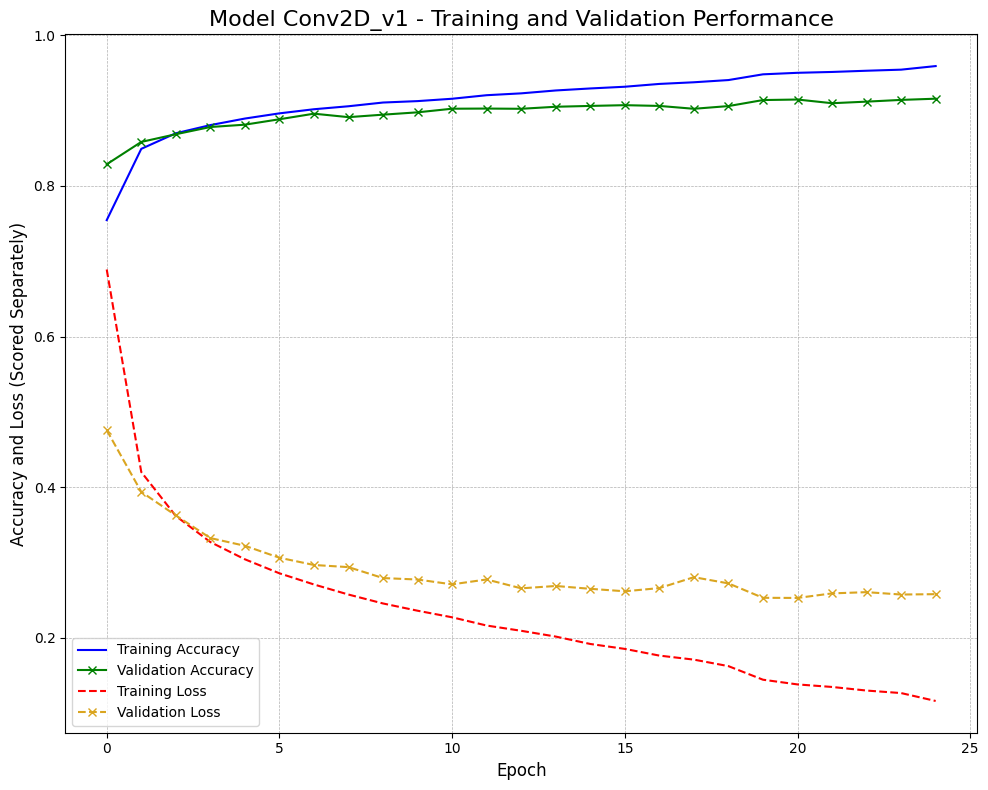

In [19]:
plot_model(history_model_conv2d_v1, model_version='Conv2D_v1')

In [ ]:
# Evaluate the model
test_loss, test_acc = model_conv2d_v1.evaluate(X_test, y_test, verbose=2)
save_metrics(loss=test_loss, accuracy=test_acc, file_name='model_metrics.json', comment='Conv2D_v1 neural net')
print(f'\nTest accuracy: {test_acc} Test loss: {test_loss}')
display_metrics(file_name='model_metrics.json')

## Conv2D v2

In [22]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Define the model architecture
model_conv2d_v2 = models.Sequential(name='conv2d_v2')
model_conv2d_v2.add(layers.Input(shape=(28, 28, 1), name='input_layer'))
#model_conv2d.add(data_augmentation)

model_conv2d_v2.add(layers.Conv2D(32, (3, 3), activation='relu', name='conv2d_layer1'))
model_conv2d_v2.add(layers.BatchNormalization(name='batchnorm_layer1'))
model_conv2d_v2.add(layers.MaxPooling2D((2, 2), name='maxpool_layer1'))
model_conv2d_v2.add(layers.Dropout(0.3, name='dropout_layer1'))

#model_conv2d_v2.add(layers.Conv2D(64, (3, 3), activation='relu', name='conv2d_layer2'))
#model_conv2d_v2.add(layers.BatchNormalization(name='batchnorm_layer2'))
#model_conv2d_v2.add(layers.MaxPooling2D((2, 2), name='maxpool_layer2'))
#model_conv2d_v2.add(layers.Dropout(0.3, name='dropout_layer2'))
#model_conv2d_v2.add(Flatten(name='flatten_layer'))
#model_conv2d_v2.add(layers.Conv2D(128, (3, 3), activation='relu', name='conv2d_layer3'))
#model_conv2d_v2.add(layers.BatchNormalization(name='batchnorm_layer3'))
#model_conv2d_v2.add(layers.MaxPooling2D((2, 2), name='maxpool_layer3'))
model_conv2d_v2.add(layers.Dropout(0.3, name='dropout_layer3'))

model_conv2d_v2.add(layers.Flatten(name='flatten_layer'))

model_conv2d_v2.add(layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001), name='dense_layer1'))
model_conv2d_v2.add(layers.BatchNormalization(name='batchnorm_dense1'))
model_conv2d_v2.add(layers.Dropout(0.5, name='dropout_dense1'))

model_conv2d_v2.add(layers.Dense(10, activation='softmax', name='output_layer'))

# Compile the model
model_conv2d_v2.compile(optimizer=Adam(learning_rate=0.0005),
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

# Define early stopping
early_stopping = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True)

# Reduce learning rate on plateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Define a learning rate scheduler
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        # return lr * tf.math.exp(-0.1)
        return float(lr * tf.math.exp(-0.1))


lr_scheduler = LearningRateScheduler(scheduler)

# Print the model summary
model_conv2d_v2.summary()



Model: "conv2d_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_layer1 (Conv2D)          │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_layer1                │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_layer1 (MaxPooling2D)   │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer1 (Dropout)        │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer3 (Dropout)        │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_layer (Flatten)         │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer1 (Dense)            │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_dense1                │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense1 (Dropout)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 694,602 (2.65 MB)

 Trainable params: 694,282 (2.65 MB)

 Non-trainable params: 320 (1.25 KB)

Epoch 1/70
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - accuracy: 0.7482 - loss: 1.0042 - val_accuracy: 0.8499 - val_loss: 0.7717 - learning_rate: 5.0000e-04
Epoch 2/70
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.8615 - loss: 0.5960 - val_accuracy: 0.8875 - val_loss: 0.4852 - learning_rate: 5.0000e-04
Epoch 3/70
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.8781 - loss: 0.5110 - val_accuracy: 0.8944 - val_loss: 0.4410 - learning_rate: 5.0000e-04
Epoch 4/70
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.8808 - loss: 0.4758 - val_accuracy: 0.8954 - val_loss: 0.4195 - learning_rate: 5.0000e-04
Epoch 5/70
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.8875 - loss: 0.4453 - val_accuracy: 0.8970 - val_loss: 0.4064 - learning_rate: 5.0000e-04
Epoch 6/70
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.8917 - loss: 0.4307 - val_accuracy: 0.8977 - val_loss: 0.4021 - learning_rate: 5.0000e-04
Epoch 7/70
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/ste

In [ ]:
%%time
# Train the model
history_model_conv2d_v2 = model_conv2d_v2.fit(
    x_train, 
    y_train, 
    batch_size=128,
    epochs=70,
    #validation_split=0.2,
    validation_data=(x_test, y_test),
    callbacks=[early_stopping, reduce_lr, lr_scheduler]
)

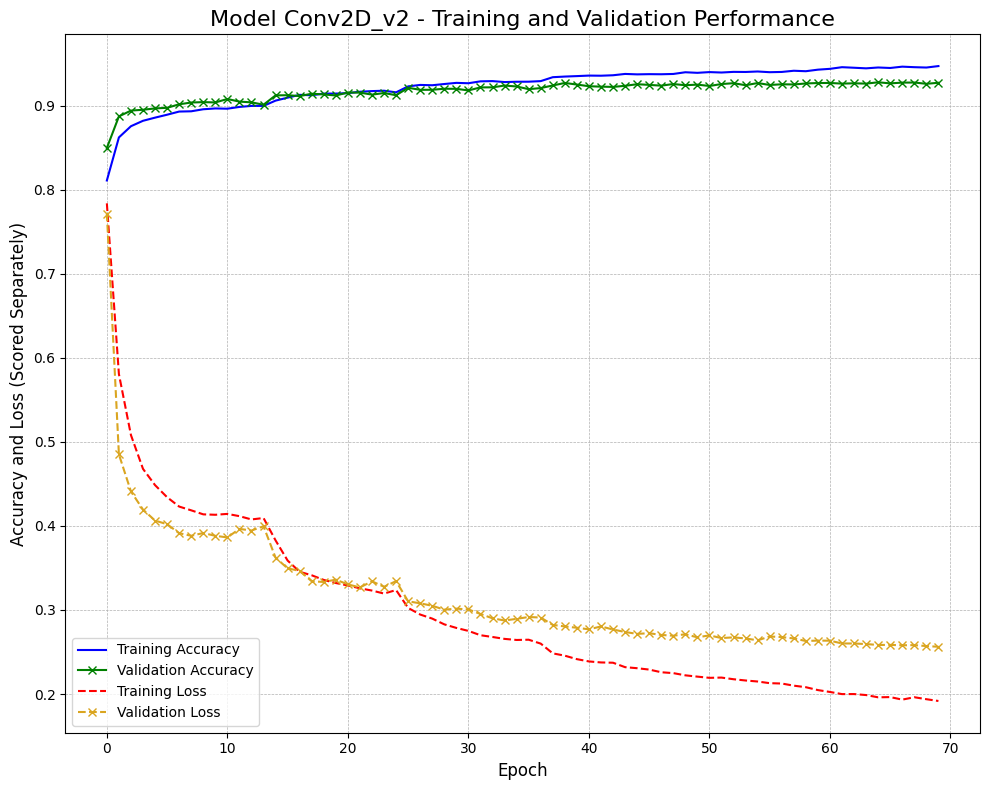

In [23]:
plot_model(history_model_conv2d_v2, model_version='Conv2D_v2')

In [43]:
# Evaluate the model
test_loss, test_acc = model_conv2d_v2.evaluate(X_test, y_test, verbose=1)
save_metrics(loss=test_loss, accuracy=test_acc, file_name='model_metrics.json', comment='Conv2D_v2 improved Conv2D_v1 model')
print(f'\nTest accuracy: {test_acc} Test loss: {test_loss}')
display_metrics(file_name='model_metrics.json')

NotFoundError: Graph execution error:

Detected at node conv2d_v2_1/conv2d_layer1_1/StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/pyt

## VGG16 v2

In [26]:
# Load and preprocess the Fashion MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

# Add a channels dimension and resize to 32x32
X_train = tf.image.resize(X_train[..., tf.newaxis], [32, 32])
X_test = tf.image.resize(X_test[..., tf.newaxis], [32, 32])

# Convert grayscale images to RGB by duplicating channels
X_train = tf.image.grayscale_to_rgb(X_train)
X_test = tf.image.grayscale_to_rgb(X_test)

# Define data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)
datagen.fit(X_train)


In [28]:
# Load the VGG16 model, without the top layers, with weights pre-trained on ImageNet
base_model = VGG16(input_shape=(32, 32, 3), include_top=False, weights='imagenet')
base_model.trainable = False

# Unfreeze the last few layers of the VGG16 model
# for layer in base_model.layers[-4:]:
#     layer.trainable = True

# Create a new model using VGG16 as the base
model_vgg16_v2 = Sequential(name='vgg16_net_v2')
model_vgg16_v2.add(base_model)
model_vgg16_v2.add(Flatten(name='flatten_layer'))
model_vgg16_v2.add(Dense(128, activation='relu', name='dense_layer1'))
model_vgg16_v2.add(BatchNormalization(name='batchnorm_layer1'))
model_vgg16_v2.add(Dropout(0.5, name='dropout_layer1'))
#model_vgg16_v2.add(Dense(64, activation='relu', name='dense_layer2'))
#model_vgg16_v2.add(BatchNormalization(name='batchnorm_layer2'))
#model_vgg16_v2.add(Dropout(0.5, name='dropout_layer2'))
model_vgg16_v2.add(Dense(10, activation='softmax', name='output_layer'))

# Compile the model
initial_learning_rate = 0.001
model_vgg16_v2.compile(optimizer=Adam(learning_rate=initial_learning_rate),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

# Define early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Define a learning rate scheduler
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return float(lr * tf.math.exp(-0.1))

lr_scheduler = LearningRateScheduler(scheduler)



Epoch 1/25


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 140ms/step - accuracy: 0.6437 - loss: 1.0737 - val_accuracy: 0.7985 - val_loss: 0.5555 - learning_rate: 0.0010
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 144ms/step - accuracy: 0.7820 - loss: 0.6076 - val_accuracy: 0.8171 - val_loss: 0.5040 - learning_rate: 0.0010
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 140ms/step - accuracy: 0.7979 - loss: 0.5637 - val_accuracy: 0.8202 - val_loss: 0.4955 - learning_rate: 0.0010
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 141ms/step - accuracy: 0.8036 - loss: 0.5434 - val_accuracy: 0.8296 - val_loss: 0.4705 - learning_rate: 0.0010
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 142ms/step - accuracy: 0.8081 - loss: 0.5273 - val_accuracy: 0.8239 - val_loss: 0.4863 - learning_rate: 0.0010
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 67s 143ms/step - accuracy: 0.8121 - loss: 0.5169 - val_accuracy: 0.8241 - val_loss: 0.4746 - learning_rate: 0.0010
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 153ms/step - accuracy: 0.8162 - loss:

In [ ]:
%%time
# Train the model
model_history_vgg16_v2 = model_vgg16_v2.fit(datagen.flow(X_train, y_train, batch_size=128),
                                      #steps_per_epoch=50,
                                      epochs=25,
                                      validation_data=(X_test, y_test),
                                      callbacks=[early_stopping, reduce_lr, lr_scheduler])

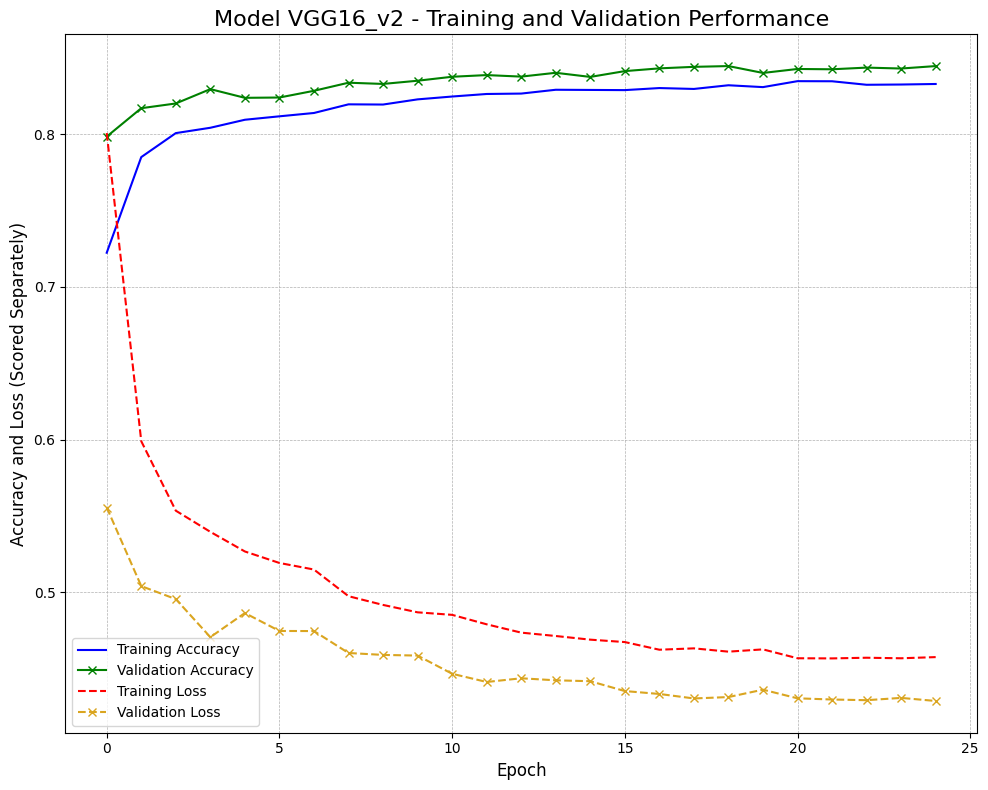

In [29]:
plot_model(model_history_vgg16_v2 , model_version='VGG16_v2')

In [57]:
# Evaluate the model
test_loss, test_acc = model_vgg16_v2.evaluate(X_test, y_test, verbose=1)
print(f'\nTest accuracy: {test_acc} Test loss: {test_loss}')
save_metrics(loss=test_loss, accuracy=test_acc, file_name='model_metrics.json', comment='VGG16_v2 neural net')
display_metrics(file_name='model_metrics.json')

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8464 - loss: 0.4191

Test accuracy: 0.8446999788284302 Test loss: 0.4287216365337372
+--------------------+--------------------+---------------------+
|        Loss        |      Accuracy      |       Comment       |
+--------------------+--------------------+---------------------+
| 0.4287216365337372 | 0.8446999788284302 | VGG16_v2 neural net |
| 0.4287216365337372 | 0.8446999788284302 | VGG16_v2 neural net |
| 0.4287216365337372 | 0.8446999788284302 | VGG16_v2 neural net |
| 0.4287216365337372 | 0.8446999788284302 | VGG16_v2 neural net |
+--------------------+--------------------+---------------------+


In [62]:
# Save the model weights
model_vgg16_v2.save_weights('model_vgg16_v2.weights.h5')

In [63]:
# Load the VGG16 model, without the top layers, with weights pre-trained on ImageNet
base_model = VGG16(input_shape=(32, 32, 3), include_top=False, weights='imagenet')

# Unfreeze the last few layers of the VGG16 model
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Create the model architecture again
model_vgg16_v2 = Sequential(name='vgg16_net_v2')
model_vgg16_v2.add(base_model)
model_vgg16_v2.add(Flatten(name='flatten_layer'))
model_vgg16_v2.add(Dense(128, activation='relu', name='dense_layer1'))
model_vgg16_v2.add(BatchNormalization(name='batchnorm_layer1'))
model_vgg16_v2.add(Dropout(0.5, name='dropout_layer1'))
#model_vgg16_v2.add(Dense(64, activation='relu', name='dense_layer2'))
#model_vgg16_v2.add(BatchNormalization(name='batchnorm_layer2'))
#model_vgg16_v2.add(Dropout(0.5, name='dropout_layer2'))
model_vgg16_v2.add(Dense(10, activation='softmax', name='output_layer'))

# Compile the model
initial_learning_rate = 0.001
model_vgg16_v2.compile(optimizer=Adam(learning_rate=initial_learning_rate),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

# Load the previously saved weights
model_vgg16_v2.load_weights('model_vgg16_v2.weights.h5')

In [64]:
# Define early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Define a learning rate scheduler
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return float(lr * tf.math.exp(-0.1))

lr_scheduler = LearningRateScheduler(scheduler)



Epoch 1/50


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


469/469 ━━━━━━━━━━━━━━━━━━━━ 118s 240ms/step - accuracy: 0.2683 - loss: 1.8680 - val_accuracy: 0.2004 - val_loss: 1.9866 - learning_rate: 0.0010
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 108s 231ms/step - accuracy: 0.6441 - loss: 0.9507 - val_accuracy: 0.7646 - val_loss: 0.6216 - learning_rate: 0.0010
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 109s 232ms/step - accuracy: 0.7471 - loss: 0.6774 - val_accuracy: 0.7564 - val_loss: 0.6428 - learning_rate: 0.0010
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 236ms/step - accuracy: 0.8066 - loss: 0.5692 - val_accuracy: 0.8582 - val_loss: 5.0263 - learning_rate: 0.0010
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 117s 249ms/step - accuracy: 0.8458 - loss: 0.4745 - val_accuracy: 0.7122 - val_loss: 0.8406 - learning_rate: 5.0000e-04
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 128s 273ms/step - accuracy: 0.8769 - loss: 0.3795 - val_accuracy: 0.8859 - val_loss: 0.3334 - learning_rate: 5.0000e-04
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 133s 284ms/step - accuracy:

ValueError: The output of the `schedule` function should be a float. Got: 0.00045241869520395994

In [ ]:
%%time
# Continue training the model
model_history_vgg16_v2_additional = model_vgg16_v2.fit(datagen.flow(X_train, y_train, batch_size=128),
                                                 epochs=50,
                                                 validation_data=(X_test, y_test),
                                                 callbacks=[early_stopping, reduce_lr, lr_scheduler])


In [ ]:
plot_model(model_history_vgg16_v2_additional, model_version='VGG16_v2 continue training')

In [ ]:
# Evaluate the model
test_loss, test_acc = model_vgg16_v2.evaluate(X_test, y_test, verbose=2)
save_metrics(loss=test_loss, accuracy=test_acc, file_name='model_metrics.json', comment='GG16_v2 neural net with additional training')
print(f'\nTest accuracy: {test_acc} Test loss: {test_loss}')
display_metrics(file_name='model_metrics.json')